In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 4** — Optimal Warehouse Product Placement

Optimising four hyperparameters of an ML model that approximates warehouse placement decisions. Output reflects improvement over an expensive baseline.

- **Optimisation Goal:** Maximise
- **Input:** 4D
- **All-time best:** +0.602 at [0.403, 0.361, 0.354, 0.347] (Week 6)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 4
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_outputs.npy')

# New data for Week 8 (Function 4)
X_w7_new_point = np.array([0.464323, 0.315250, 0.374494, 0.394655], dtype=np.float64)
Y_w7_new_point = np.array([-1.595582441884488], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 4: ", X_unique)
print("Updated Outputs (Y) - Function 4: ", Y_updated)

Updated Inputs (X) - Function 4:  [[0.03782483 0.66485335 0.16198218 0.25392378]
 [0.11245    0.456812   0.901233   0.005678  ]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.17034731 0.75695908 0.27652049 0.5312315 ]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.28213837 0.50598691 0.53053084 0.09630162]
 [0.32607578 0.4723669  0.453192   0.10588734]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.387195   0.490423   0.43071    0.405493  ]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.402567   0.361014   0.353681   0.347064  ]
 [0.428988   0.443109   0.30979    0.428981  ]
 [0.434904   0.399307   0.463215   0.450952  ]
 [0.435024   0.412464   0.436414   0.423453  ]
 [0.464323   0.31525    0.374494   0.394655  ]
 [0.48859419 0.2119651  0.

## Output Analysis

- Last week (w6) I got the result of +0.602 (all-time best) and this week (w7) got a regression -1.596.

- **Real-World Implication:** Despite reducing beta from 3.0 to 2.0 and introducing a focused grid, the w7 query produced the second-worst result in the project. 
    - The w7 input at [0.464, 0.315, 0.374, 0.395] is close to the W6 best in x3 and x4, but x1 moved higher (0.464 vs 0.403) and x2 moved lower (0.315 vs 0.361). 
        - This narrow change was enough to fall off the peak entirely.

- **Model Clues:** The positive results (w3: +0.396, w6: +0.602) both had inputs tightly balanced in [0.35, 0.46]. 
    - The negative results consistently involve at least one dimension drifting outside this range. 
    - The peak is extremely narrow and the landscape is highly non-smooth, as documented in the brief.

- **Key change for w8:** Restore beta to 3.0 AND use a very tight focused grid (std=0.02) centred precisely on the w6 all-time best. 
    - The combination of high beta and tight grid gives both precision and protection against committing to a single bad point.

## Bayesian Optimisation — Gaussian Process Regressor

- **Model:** ConstantKernel × Matern (nu=1.5, ARD) + WhiteKernel with Yeo-Johnson output transformation.

- **Changes for w8:**
    - nu=1.5 retained — the rugged, cliff-prone landscape requires a less-smooth kernel.

    - ARD retained — essential for identifying which of the four warehouse dimensions are driving the positive results.

    - Yeo-Johnson transformation retained — the output range from -21.857 to +0.602 requires it.

    - n_restarts_optimizer increased to 25 to ensure ARD length scales are well-optimised given the new W7 outlier data point.

- **Intended impact:** Allow the GP to process the w7 regression as boundary evidence, it now knows that [0.464, 0.315, 0.374, 0.395] is outside the positive zone, and steer w8 back toward the confirmed w6 peak.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

# ARD Matern 1.5 — best suited to the rugged, cliff-prone 4D landscape
kernel = C(1.0) * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], nu=1.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

Original Y: [-13.70274694 -21.85692717 -10.06963343 -26.56182083 -11.56574199
 -12.75832422 -16.50715856 -12.68168498 -11.69993246  -7.96677535
  -6.70208925 -16.05376511  -1.22497255 -19.44155762 -17.04923465
   0.60175052  -0.51817613  -0.79124631   0.39597537  -1.59558244
 -17.81799934  -4.02554228 -12.74176599 -16.6791152  -19.98949793
 -29.4270914  -13.52764887 -13.12278233 -16.02639977 -15.48708254
 -23.1394284  -26.85778644 -14.60139663 -22.10828779 -32.62566022
 -27.31639636 -28.90327367]
Transformed Y: [ 0.0306274  -0.80988236  0.43446781 -1.26593569  0.26532436  0.13342866
 -0.2671289   0.14183275  0.2503602   0.68040037  0.83391368 -0.2196893
  1.58282124 -0.56844993 -0.32352113  1.91012033  1.69920834  1.65315693
  1.86839442  1.52492469 -0.40290984  1.17767412  0.13524359 -0.28505552
 -0.62370686 -1.53581254  0.04958306  0.09359214 -0.21681785 -0.16003337
 -0.93594608 -1.2940677  -0.06595033 -0.8347009  -1.83105113 -1.33753967
 -1.48687497]

Fitted kernel: 2.82**2 * Matern

## **Acquisition Function**: UCB (beta=3.0) with Tight Focused Grid

- **Strategy:** Beta restored to 3.0 (from 2.0 last week). 
    - The w7 regression confirms this landscape is too rugged to reduce exploration prematurely.

- **Key change for w8:** Tight focused grid centred on the w6 all-time best [0.403, 0.361, 0.354, 0.347] with std=0.02. 
    - A 80/20 focused/uniform split. 
    - The combination of high beta and a tight grid provides both precision (stay near the confirmed positive zone) and protection (explore nearby uncertainty rather than random noise).

- **Intended impact:** Return to positive territory and surpass +0.602.

In [4]:
def upper_confidence_bound(X, model, beta=3.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# Tight focused grid centred on W6 all-time best
w6_best = np.array([0.402567, 0.361014, 0.353681, 0.347064])

x_focused = np.clip(
    np.random.normal(loc=w6_best, scale=0.02, size=(24000, 4)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (6000, 4))
x_grid = np.vstack([x_focused, x_uniform])

ucb_values = upper_confidence_bound(x_grid, model, beta=3.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f'W6 best coordinates: {w6_best}')
print(f'Strategic Week 8 Query (Function 4): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}')

W6 best coordinates: [0.402567 0.361014 0.353681 0.347064]
Strategic Week 8 Query (Function 4): 0.348650-0.393784-0.359305-0.401263


## **Visualisation** - Optimisation Progress

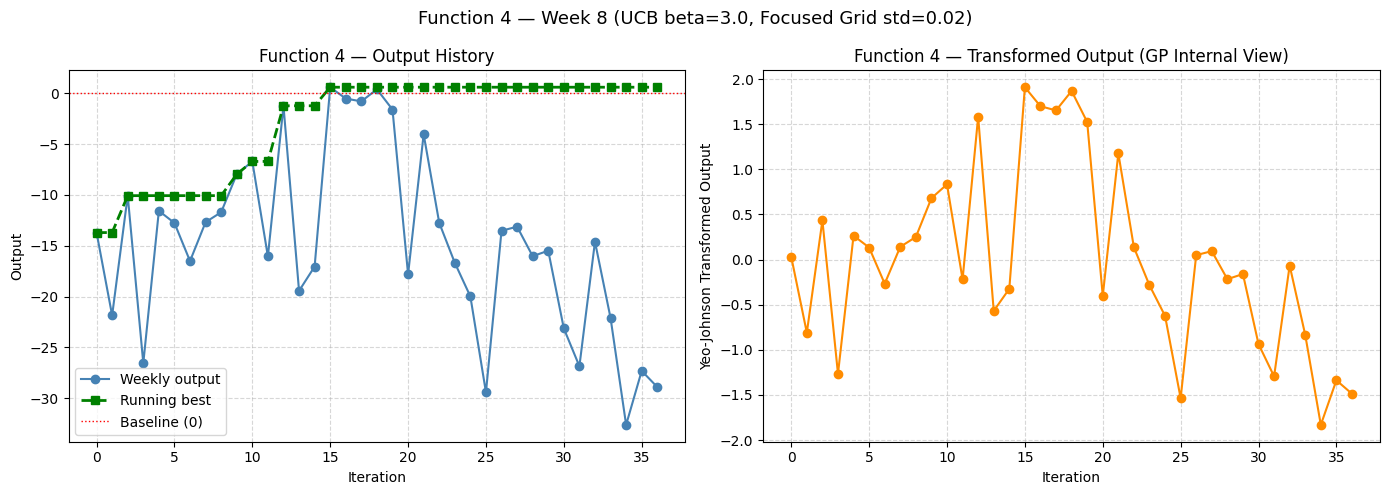

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1, label='Baseline (0)')
axes[0].set_title('Function 4 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Transformed Y to show GP's internal view
axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 4 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 4 — Week 8 (UCB beta=3.0, Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()